In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

import warnings
warnings.filterwarnings("ignore")

import itertools
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error
import math
from sklearn.metrics import mean_absolute_error
from pmdarima import auto_arima

In [2]:
df = pd.read_excel(r"C:\Users\Aditya P J\Documents\Kuliah\Semester 7\Forecast\Proyek\Data\Data_BBCA_2015_sampai_sekarang.xlsx")
df.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500


In [3]:
df = df.drop(df.index[0:2])
df.head(10)

,Price,Close,High,Low,Open,Volume
2,2015-01-02 00:00:00,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05 00:00:00,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06 00:00:00,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07 00:00:00,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08 00:00:00,2130.166504,2158.897073,2130.166504,2154.792706,54457000
7,2015-01-09 00:00:00,2121.956787,2146.582978,2121.956787,2138.374248,108957500
8,2015-01-12 00:00:00,2134.270508,2134.270508,2101.435577,2121.957409,81651000
9,2015-01-13 00:00:00,2134.270508,2142.479241,2130.166141,2142.479241,36024000
10,2015-01-14 00:00:00,2121.956787,2138.374248,2121.956787,2138.374248,29728000
11,2015-01-15 00:00:00,2126.061279,2142.478741,2126.061279,2126.061279,27580500


In [4]:
df['Price'] = pd.to_datetime(df['Price'])

df = df.rename(columns={'Price': 'Date'})

df = df.sort_values("Date")
df.head()

,Date,Close,High,Low,Open,Volume
2,2015-01-02,2171.209473,2179.418204,2158.896375,2179.418204,29302500
3,2015-01-05,2167.105957,2167.105957,2154.792855,2158.897222,25434500
4,2015-01-06,2150.688477,2167.105946,2134.271007,2134.271007,48681500
5,2015-01-07,2154.791992,2167.105089,2142.478895,2142.478895,40334000
6,2015-01-08,2130.166504,2158.897073,2130.166504,2154.792706,54457000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2653 entries, 2 to 2654
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    2653 non-null   datetime64[ns]
 1   Close   2653 non-null   object        
 2   High    2653 non-null   object        
 3   Low     2653 non-null   object        
 4   Open    2653 non-null   object        
 5   Volume  2653 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 124.5+ KB


In [6]:
for col in ['Close', 'High', 'Low', 'Open', 'Volume']:
    df[col] = (
        df[col]
        .astype(str)                     # pastikan string
        .str.replace(',', '', regex=False)  # hapus koma ribuan
        .str.replace(' ', '', regex=False)  # hapus spasi
        .astype(float)                   # ubah ke float
    )

In [7]:
# Jadikan Date sebagai index
df = df.set_index('Date')

# Ambil hanya kolom Close
close = df['Close']

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2653 entries, 2015-01-02 to 2025-10-07
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2653 non-null   float64
 1   High    2653 non-null   float64
 2   Low     2653 non-null   float64
 3   Open    2653 non-null   float64
 4   Volume  2653 non-null   float64
dtypes: float64(5)
memory usage: 124.4 KB


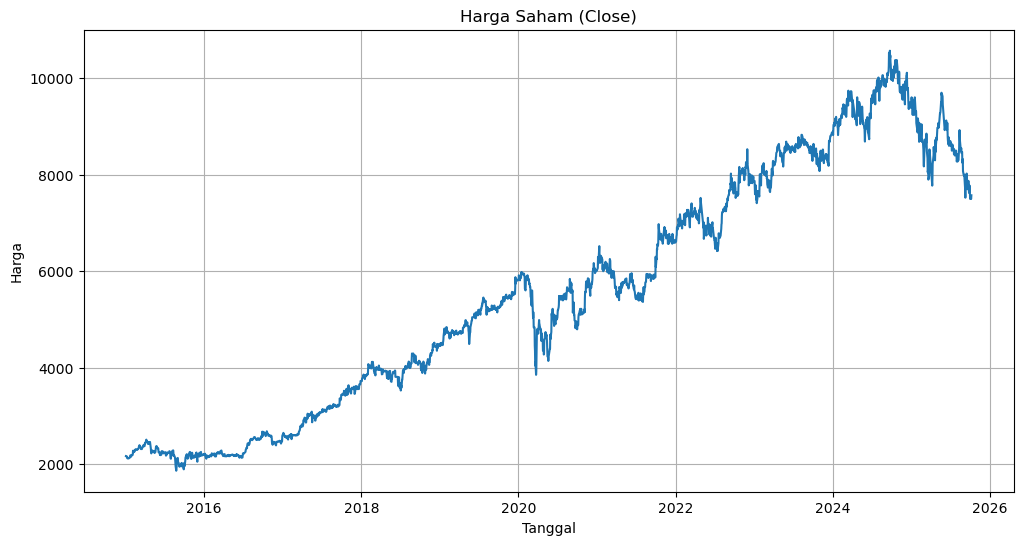

In [9]:
plt.figure(figsize=(12,6))
plt.plot(close)
plt.title('Harga Saham (Close)')
plt.xlabel('Tanggal')
plt.ylabel('Harga')
plt.grid(True)
plt.show()

--- Hasil Uji ADF (Data Asli) ---
ADF Statistic: -1.1463479213905212
p-value: 0.6962396558205224
⚠️ Data belum stasioner, lakukan differencing (d = 1)


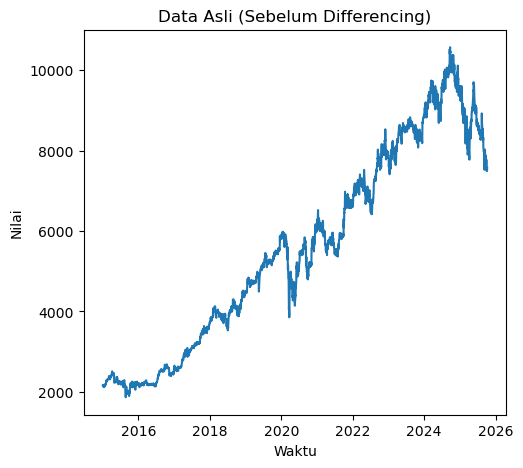

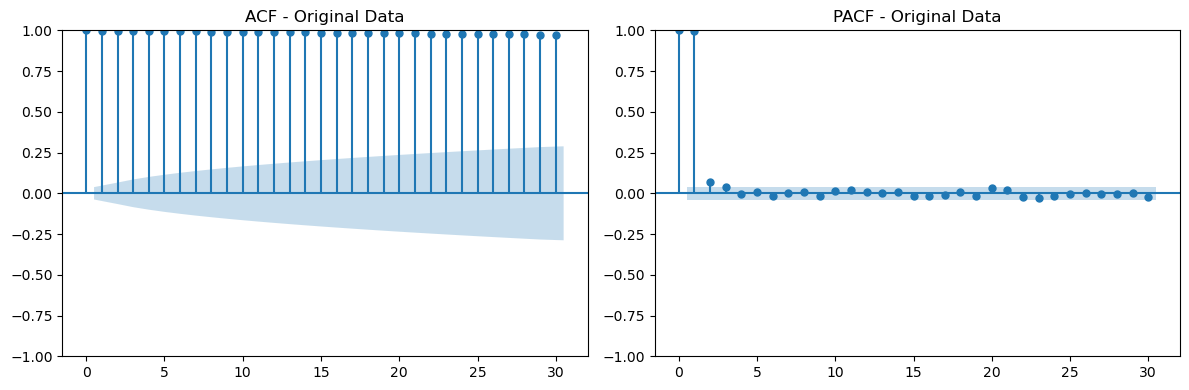

In [23]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ---Uji ADF pada data asli ---
adf_result = adfuller(close.dropna())
print('--- Hasil Uji ADF (Data Asli) ---')
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])

if adf_result[1] < 0.05:
    print("✅ Data sudah stasioner (tidak perlu differencing, d = 0)")
    close_diff = close
    d = 0
else:
    print("⚠️ Data belum stasioner, lakukan differencing (d = 1)")
    close_diff = close.diff().dropna()
    d = 1

# ---Plot Data Asli vs Setelah Differencing ---
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(close)
plt.title("Data Asli (Sebelum Differencing)")
plt.xlabel("Waktu")
plt.ylabel("Nilai")

# --- Plot ACF & PACF untuk data asli ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(close.dropna(), lags=30, ax=axes[0])
axes[0].set_title("ACF - Original Data")
plot_pacf(close.dropna(), lags=30, ax=axes[1], method='ywm')
axes[1].set_title("PACF - Original Data")
plt.tight_layout()
plt.show()


=== Hasil Uji ADF Setelah Log Differencing ===
ADF Statistic: -39.69658035185298
p-value: 0.0
✅ Data sudah stasioner setelah log differencing


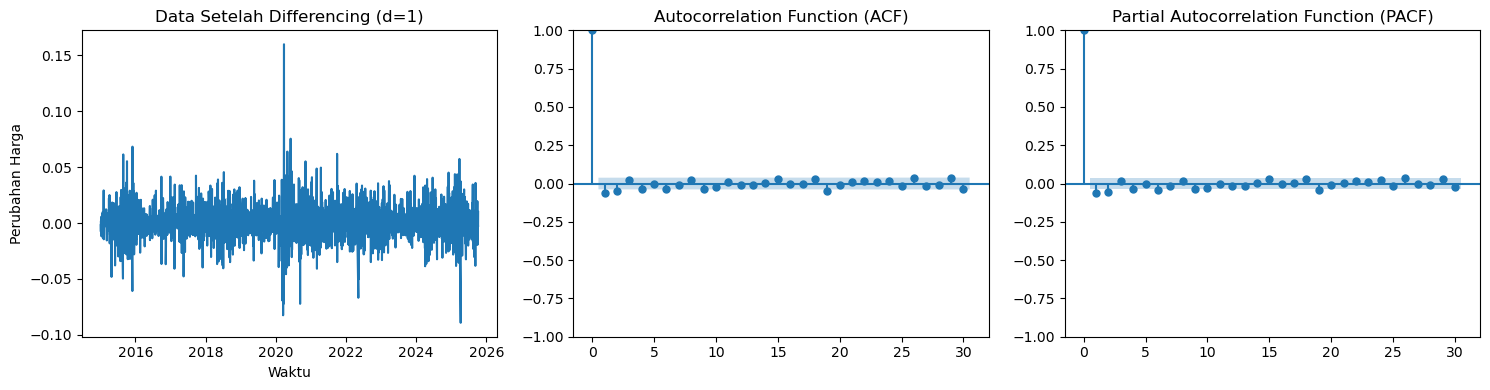

In [12]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Uji ADF setelah differencing
if d == 1:
    # Coba log differencing jika data finansial
    close_original = df['Close']
    close_diff = np.log(df['Close']).diff().dropna()
    adf_result_log_diff = adfuller(close_diff)
    
    print('\n=== Hasil Uji ADF Setelah Log Differencing ===')
    print('ADF Statistic:', adf_result_log_diff[0])
    print('p-value:', adf_result_log_diff[1])
    
    if adf_result_log_diff[1] < 0.05:
        print("✅ Data sudah stasioner setelah log differencing")
    else:
        print("⚠️ Data masih belum stasioner, pertimbangkan d=2")

# --- Plot Data Setelah Differencing + ACF & PACF ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot data setelah differencing
axes[0].plot(close_diff)
axes[0].set_title("Data After Differentiating (d=1)")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Perubahan Harga")

# Plot ACF
plot_acf(close_diff, lags=30, ax=axes[1])
axes[1].set_title("Autocorrelation Function (ACF)")

# Plot PACF
plot_pacf(close_diff, lags=30, ax=axes[2], method='ywm')
axes[2].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()



=== Split Data Differencing ===
Ukuran train_diff: 2386
Ukuran test_diff : 266


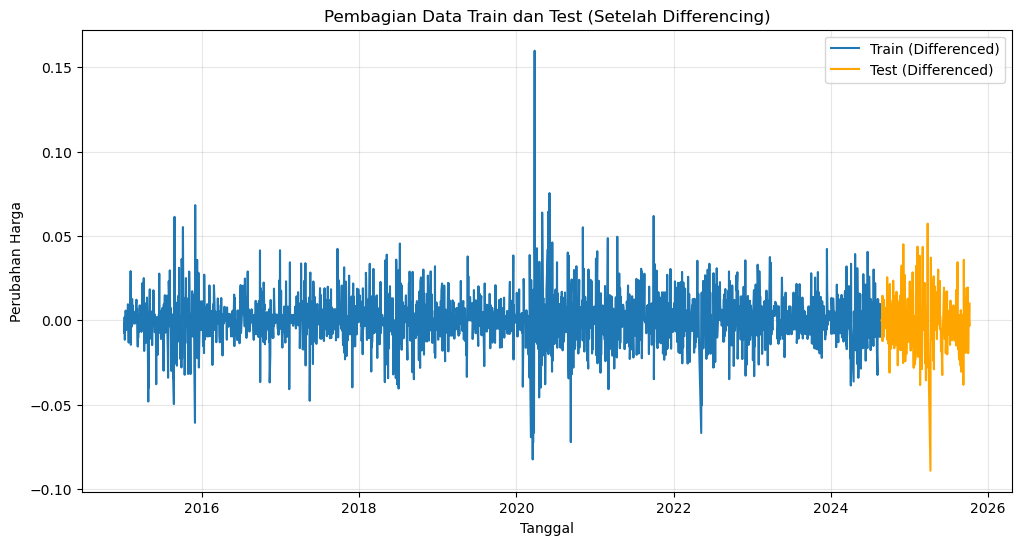

In [19]:
# 2. Split data yang sudah di-differencing
split_ratio = 0.9
split_index = int(len(close_diff) * split_ratio)

train_diff = close_diff.iloc[:split_index]
test_diff = close_diff.iloc[split_index:]

print(f"\n=== Split Data Differencing ===")
print(f"Ukuran train_diff: {len(train_diff)}")
print(f"Ukuran test_diff : {len(test_diff)}")

# 3. Plot data differencing
plt.figure(figsize=(12, 6))
plt.plot(train_diff, label='Train (Differenced)')
plt.plot(test_diff, label='Test (Differenced)', color='orange')
plt.title('Pembagian Data Train dan Test (Setelah Differencing)')
plt.xlabel('Tanggal')
plt.ylabel('Perubahan Harga')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [21]:
train = close.iloc[:split_index]
test = close.iloc[split_index:]

print("=== INFO DATA ===")
print("Panjang train:", len(train))
print("Panjang test :", len(test))

# --- Bersihkan NaN/inf secara eksplisit ---
train_clean = train.replace([np.inf, -np.inf], np.nan).dropna()
test_clean = test.replace([np.inf, -np.inf], np.nan).dropna()

print("\nJumlah NaN di train:", train_clean.isna().sum())
print("Jumlah NaN di test :", test_clean.isna().sum())

=== INFO DATA ===
Panjang train: 2386
Panjang test : 267

Jumlah NaN di train: 0
Jumlah NaN di test : 0


In [23]:
# 4. Bersihkan data
train_clean = train_diff.replace([np.inf, -np.inf], np.nan).dropna()
test_clean = test_diff.replace([np.inf, -np.inf], np.nan).dropna()

In [25]:
print("\n=== Mencari Parameter Terbaik dengan Auto ARIMA ===")

auto_model = auto_arima(
    train_clean,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=d,
    seasonal=False,
    m=1,
    information_criterion='bic',
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True,
    approximation=False
)

print("\n=== Model Terbaik dari Auto ARIMA ===")
print(auto_model.summary())
best_order = auto_model.order
print(f"Best ARIMA order: {best_order}")


=== Mencari Parameter Terbaik dengan Auto ARIMA ===
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=-11651.479, Time=0.34 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=-12365.255, Time=0.28 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=2.88 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=-11659.256, Time=0.23 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=-12723.482, Time=1.81 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : BIC=-12849.762, Time=1.36 sec
 ARIMA(4,1,0)(0,0,0)[0] intercept   : BIC=-12939.120, Time=3.43 sec
 ARIMA(5,1,0)(0,0,0)[0] intercept   : BIC=-12984.496, Time=1.35 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : BIC=-13149.050, Time=6.17 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : BIC=-13333.224, Time=5.21 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : BIC=-13355.562, Time=4.81 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : BIC=-13380.374, Time=4.36 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=inf, Time=5.43 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept 

In [26]:
# 5. Fit model final pada data differencing lengkap
final_model = ARIMA(close_diff, order=best_order)
final_model_fit = final_model.fit()

print("\n=== Model Final Fitted ===")
print(final_model_fit.summary())


=== Model Final Fitted ===
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2652
Model:                 ARIMA(2, 1, 1)   Log Likelihood                7441.796
Date:                Wed, 12 Nov 2025   AIC                         -14875.592
Time:                        08:36:54   BIC                         -14852.062
Sample:                             0   HQIC                        -14867.075
                               - 2652                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0687      0.014     -5.056      0.000      -0.095      -0.042
ar.L2         -0.0548      0.013     -4.278      0.000      -0.080      -0.030
ma.L1         -0.9987   

In [29]:
print("\n=== DEBUG NILAI TRAIN ===")
print("Tipe data train_:", type(train))
print("Panjang train_:", len(train))
print("Jumlah NaN:", train.isna().sum())
print("Ada inf? ", np.isinf(train).sum())
print("5 data pertama:")
print(train.head())



=== DEBUG NILAI TRAIN ===
Tipe data train_: <class 'pandas.core.series.Series'>
Panjang train_: 2386
Jumlah NaN: 0
Ada inf?  0
5 data pertama:
Date
2015-01-02    2171.209473
2015-01-05    2167.105957
2015-01-06    2150.688477
2015-01-07    2154.791992
2015-01-08    2130.166504
Name: Close, dtype: float64


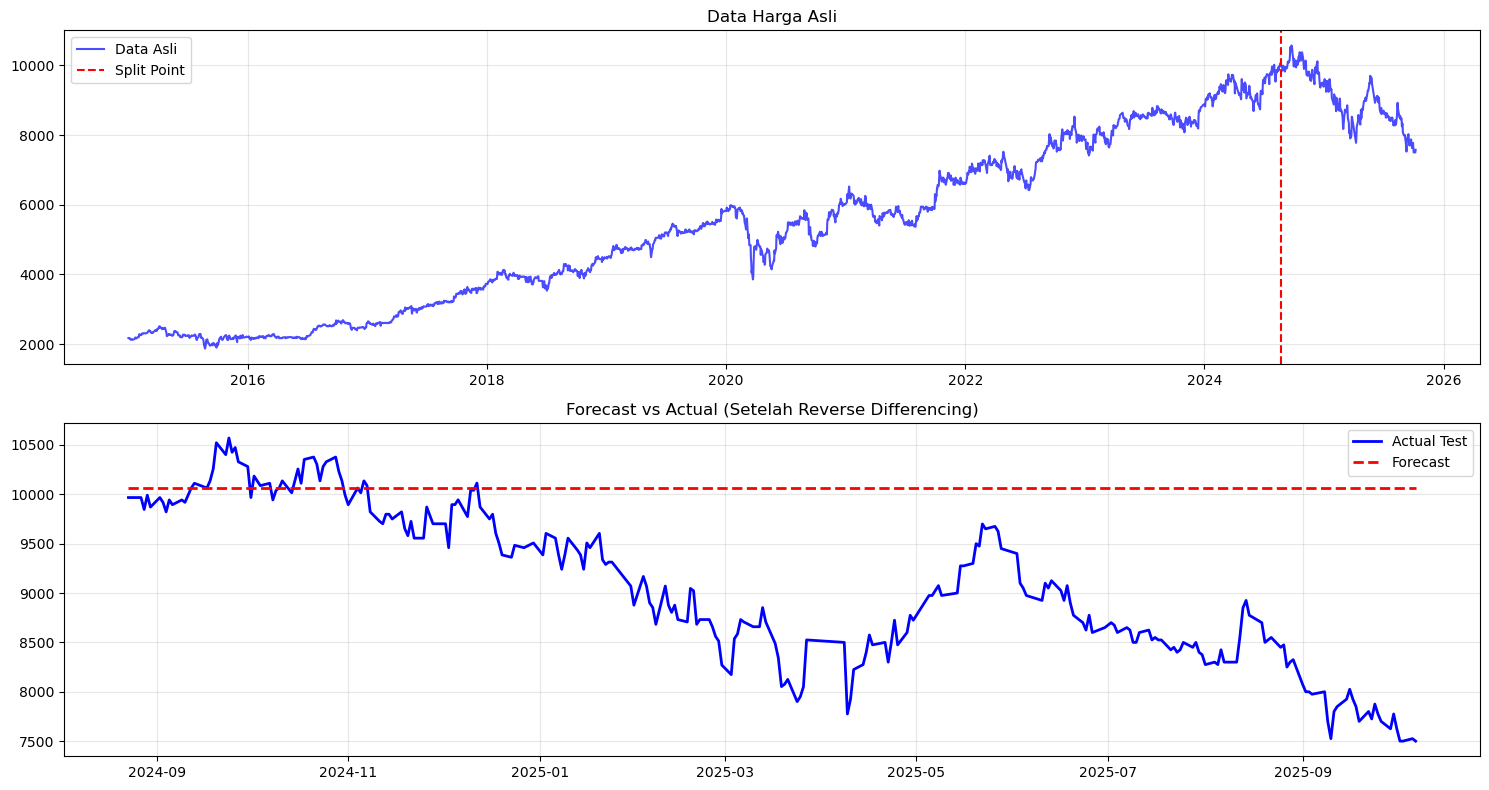


=== Evaluasi Model ===
MAE: 1039.2689
MSE: 1601673.3240
RMSE: 1265.5723
MAPE: 12.24%


In [31]:
# 6. FORECASTING dan REVERSE DIFFERENCING
# Forecast untuk periode test
forecast_steps = len(test_clean)
forecast_diff = final_model_fit.forecast(steps=forecast_steps)

# Reverse differencing untuk mendapatkan forecast dalam skala original
def reverse_differencing(forecast_diff, last_original_value, original_data):
    """
    Mengembalikan forecast dari differencing ke skala original
    """
    # last_original_value adalah nilai terakhir sebelum periode forecast
    last_original = original_data.iloc[split_index-1]  # -1 karena differencing mengurangi 1 observasi
    
    # Reverse differencing: Y_t = Y_{t-1} + ΔY_t
    forecast_original = []
    current = last_original
    
    for diff_value in forecast_diff:
        current = current + diff_value
        forecast_original.append(current)
    
    return np.array(forecast_original)

# Untuk log differencing, gunakan fungsi ini:
def reverse_log_differencing(forecast_log_diff, last_original_value, original_data):
    """
    Mengembalikan forecast dari log differencing ke skala original
    """
    last_original = original_data.iloc[split_index-1]
    last_log = np.log(last_original)
    
    forecast_original = []
    current_log = last_log
    
    for log_diff_value in forecast_log_diff:
        current_log = current_log + log_diff_value
        forecast_original.append(np.exp(current_log))
    
    return np.array(forecast_original)

# Pilih fungsi reverse berdasarkan jenis differencing
forecast_original = reverse_differencing(forecast_diff, close.iloc[split_index-1], close_original)

# 7. Plot hasil forecast vs actual
plt.figure(figsize=(15, 8))

# Plot data asli
plt.subplot(2, 1, 1)
plt.plot(close_original.index, close_original, label='Data Asli', color='blue', alpha=0.7)
plt.axvline(x=close_original.index[split_index], color='red', linestyle='--', label='Split Point')
plt.title('Data Harga Asli')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot forecast vs actual
plt.subplot(2, 1, 2)
plt.plot(test_clean.index, close_original.iloc[split_index:split_index+len(test_clean)], 
         label='Actual Test', color='blue', linewidth=2)
plt.plot(test_clean.index, forecast_original, 
         label='Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Forecast vs Actual (Setelah Reverse Differencing)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 8. Evaluasi model
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual_original = close_original.iloc[split_index:split_index+len(test_clean)].values

mae = mean_absolute_error(actual_original, forecast_original)
mse = mean_squared_error(actual_original, forecast_original)
rmse = np.sqrt(mse)

print(f"\n=== Evaluasi Model ===")
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {np.mean(np.abs((actual_original - forecast_original) / actual_original)) * 100:.2f}%")

In [47]:
# === 8. Visualisasi Hasil Prediksi ===
plt.figure(figsize=(12,6))
plt.plot(train, label='Data Train')
plt.plot(test, label='Data Aktual (Test)', color='orange')
plt.plot(pred_test, label='Prediksi ARIMA', color='green')
plt.title('Hasil Prediksi ARIMA pada Data Test')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan')
plt.legend()
plt.show()


NameError: name 'y_true' is not defined

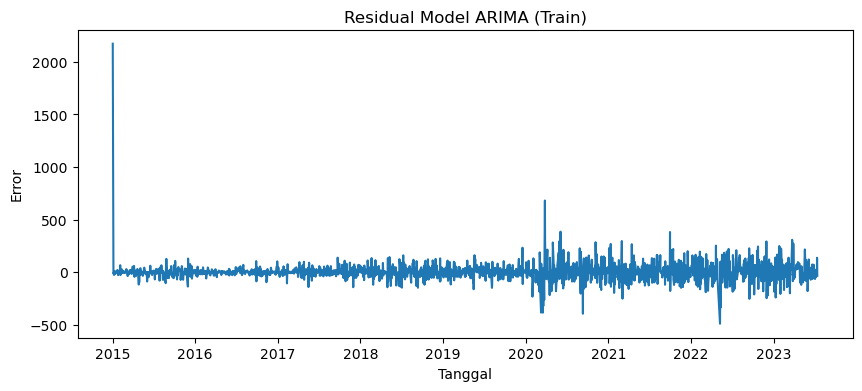


Statistik Residual:
count    2122.000000
mean        4.385828
std        85.906715
min      -487.693281
25%       -24.709532
50%         0.914749
75%        28.857371
max      2171.209473
dtype: float64


In [65]:
# === 9. Residual untuk Analisis Lanjut / LSTM ===
residuals = train - pred_train
residuals = residuals.dropna()

plt.figure(figsize=(10,4))
plt.plot(residuals)
plt.title('Residual Model ARIMA (Train)')
plt.xlabel('Tanggal')
plt.ylabel('Error')
plt.show()

print("\nStatistik Residual:")
print(residuals.describe())

In [29]:
plt.figure(figsize=(12,6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', color='red')
plt.title('Prediksi Harga Saham BBCA - Auto ARIMA')
plt.xlabel('Tanggal')
plt.ylabel('Harga Saham (Close)')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'train' is not defined

<Figure size 1200x600 with 0 Axes>

In [22]:

# -------------------------
# Forecast final (30 hari)
# -------------------------
fc_steps = 30
forecast_final = best_res.get_forecast(steps=fc_steps)
fc_mean = forecast_final.predicted_mean
fc_ci = forecast_final.conf_int()

plt.figure(figsize=(12,6))
plt.plot(close, label='history')
plt.plot(fc_mean.index, fc_mean, label='forecast', color='red')
plt.fill_between(fc_ci.index, fc_ci.iloc[:,0], fc_ci.iloc[:,1], alpha=0.3)
plt.legend()
plt.title(f'Forecast {fc_steps} steps ahead')
plt.show()

# Jika ingin, cetak koefisien model dan interpretasi singkat
print("\nKoefisien model:")
print(best_res.params)


NameError: name 'best_res' is not defined